In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


In [2]:
data = {
    "Age": [20, 22, 25, 28, 30, 32, 35, 38, 40, 42, 45, 48, 50, 52, 55],
    "Income": [2.0, 2.5, 3.0, 3.2, 3.8, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5],
    "Buy": [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
print(df)

    Age  Income  Buy
0    20     2.0    0
1    22     2.5    0
2    25     3.0    0
3    28     3.2    0
4    30     3.8    0
5    32     4.0    1
6    35     4.5    1
7    38     5.0    1
8    40     5.5    1
9    42     6.0    1
10   45     6.5    1
11   48     7.0    1
12   50     7.5    1
13   52     8.0    1
14   55     8.5    1


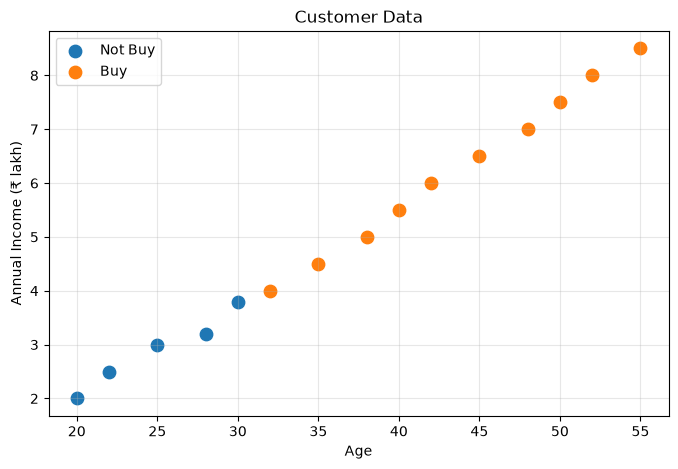

In [3]:
plt.figure(figsize=(8, 5))

for label, name in [(0, "Not Buy"), (1, "Buy")]:
    subset = df[df["Buy"] == label]
    plt.scatter(subset["Age"], subset["Income"], s=80, label=name)

plt.xlabel("Age")
plt.ylabel("Annual Income (₹ lakh)")
plt.title("Customer Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [4]:
X = df[["Age", "Income"]]
y = df["Buy"]

print("X:")
print(X)
print("\ny:")
print(y)


X:
    Age  Income
0    20     2.0
1    22     2.5
2    25     3.0
3    28     3.2
4    30     3.8
5    32     4.0
6    35     4.5
7    38     5.0
8    40     5.5
9    42     6.0
10   45     6.5
11   48     7.0
12   50     7.5
13   52     8.0
14   55     8.5

y:
0     0
1     0
2     0
3     0
4     0
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
Name: Buy, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 10
Testing samples : 5


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First five scaled training rows:")
print(X_train_scaled[:5])


First five scaled training rows:
[[-1.48988855 -1.37620908]
 [ 0.05804761 -0.06802554]
 [ 1.41249174  1.5017947 ]
 [ 0.25153962  0.19361116]
 [-0.71592047 -0.69595364]]


In [7]:
k = 3

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")
print("K =", k)


KNN model trained successfully.
K = 3


In [8]:
y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)

results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = y_pred
results["Probability_of_Buying"] = y_prob[:, 1]

print(results.sort_index())


    Age  Income  Actual  Predicted  Probability_of_Buying
0    20     2.0       0          0               0.000000
3    28     3.2       0          0               0.333333
9    42     6.0       1          1               1.000000
11   48     7.0       1          1               1.000000
12   50     7.5       1          1               1.000000


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



Confusion Matrix:
[[2 0]
 [0 3]]


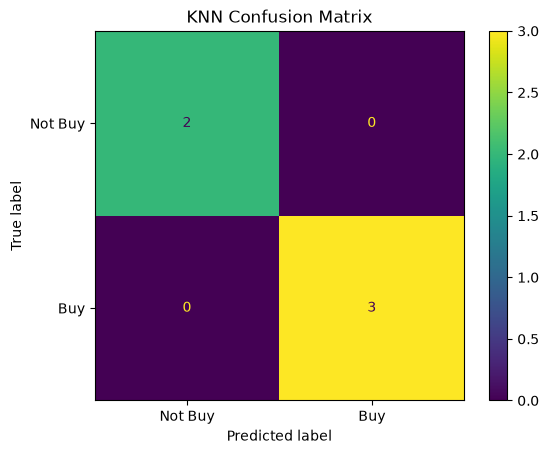

In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Buy", "Buy"]
).plot()

plt.title("KNN Confusion Matrix")
plt.show()


In [11]:
new_customers = pd.DataFrame({
    "Age": [24, 36, 50],
    "Income": [3.0, 4.8, 7.5]
})

new_customers_scaled = scaler.transform(new_customers)

predictions = knn.predict(new_customers_scaled)
probabilities = knn.predict_proba(new_customers_scaled)[:, 1]

prediction_table = new_customers.copy()
prediction_table["Predicted_Class"] = predictions
prediction_table["Buy_Probability"] = probabilities.round(3)
prediction_table["Result"] = prediction_table["Predicted_Class"].map({0: "Not Buy", 1: "Buy"})

print(prediction_table)


   Age  Income  Predicted_Class  Buy_Probability   Result
0   24     3.0                0              0.0  Not Buy
1   36     4.8                1              1.0      Buy
2   50     7.5                1              1.0      Buy


In [12]:
k_values = range(1, 10)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    prediction = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, prediction))

for k, acc in zip(k_values, accuracies):
    print(f"K = {k}: Accuracy = {acc:.3f}")


K = 1: Accuracy = 1.000
K = 2: Accuracy = 1.000
K = 3: Accuracy = 1.000
K = 4: Accuracy = 1.000
K = 5: Accuracy = 1.000
K = 6: Accuracy = 1.000
K = 7: Accuracy = 0.600
K = 8: Accuracy = 0.600
K = 9: Accuracy = 0.600


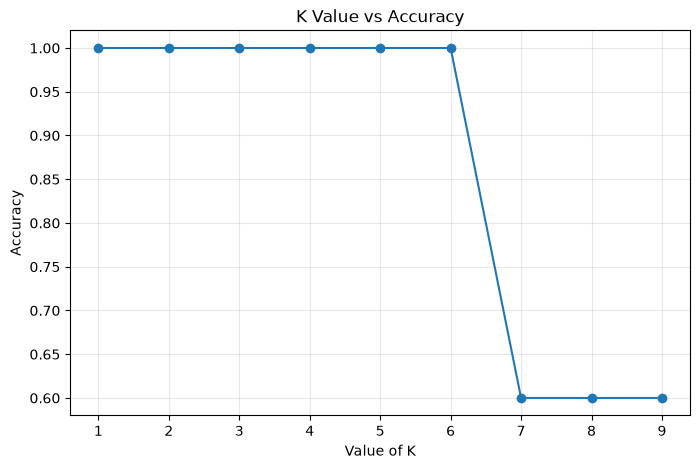

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), accuracies, marker="o")

plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()
